In [ ]:
# Install required packages
!pip install --upgrade --quiet 'natural-pdf[export,ai]>=0.5.0'
!pip install --upgrade --quiet easyocr
!pip install --upgrade --quiet surya-ocr

print('✓ Packages installed!')

**Slides:** [slides.pdf](./slides.pdf)

# OCR: Recognizing text

Sometimes you can't actually get the text off of the page. It's an *image* of text instead of being actual text.

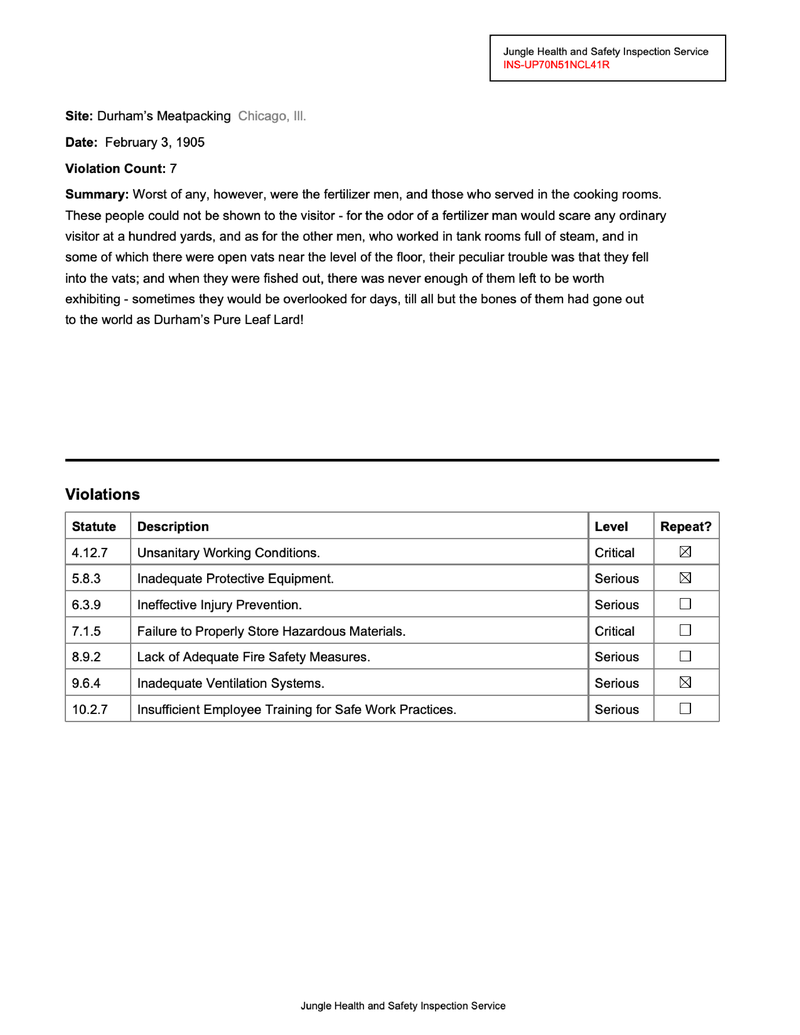

In [1]:
from natural_pdf import PDF

pdf = PDF("https://github.com/jsoma/natural-pdf/raw/refs/heads/main/pdfs/needs-ocr.pdf")
page = pdf.pages[0]
page.show(width=800)

Looks the same as the last one, right? But when we try to extract the text...

In [2]:
text = page.extract_text()
print(text)

Nothing! **It's time for OCR.**

There are a looooot of OCR engines out there, and one of the things that makes Natural PDF nice is that it supports multiples. Figuring out which one is the "best" isn't as tough when you can just run them all right after each other.

The default is [EasyOCR](https://github.com/JaidedAI/EasyOCR) which usually works fine. But what happens when we try it with this document?

In [3]:
page.apply_ocr()

Using CPU. Note: This module is much faster with a GPU.
/Users/soma/Development/natural-pdf/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


<Page number=1 index=0>

<Page number=1 index=0>

In [4]:
text = page.extract_text()
print(text)

Jungle Health and Safety Inspection Service
INS-UPZONSINCL4IR
Site: Durham's Meatpacking Chicago, III:
Date: February 3, 1905
Violation Count: 7
Summary: Worst of any, however, were the fertilizer men, and those who served in the cooking rooms
These people could not be shown to the visitor for the odor of a fertilizer man would scare any ordinary
visitor at a hundred yards, and as for the other men, who worked in tank rooms full of steam, and in
some of which there were open vats near the level of the floor; their peculiar trouble was thattheyfell
into the vats; and when they were fished out, there was never enough of them left to be worth
exhibiting sometimestheywould be overlooked for days, till all but the bones of them had gone out
to the world as Durham's Pure Leaf Lardl
Violations
Statute Description Level Repeat?
4.12.7 Unsanitary Working Conditions. Critical
5.8.3 Inadequate Protective Equipment Serious
6.3.9 Ineffective Injury Prevention_ Serious
7.1.5 Failure to Properly Stor

It does pretty well! The only issue is it gives me **Durham's Pure Leaf Lardl** instead of **Durham's Pure Leaf Lard!** I don't need to know why, though, really, because I can just try some other engine! You can also fool around with the options - some of the the lowest-hanging fruit is increasing the resolution of the OCR. The default at the moment is 150, you can try upping to 300 for (potentially) better results.

To fix this I'll both up the resolution and try another OCR engine (we have a bushel of them).

In [5]:
page.apply_ocr(engine='rapidocr')
#page.apply_ocr(engine='surya')

[INFO] 2026-03-06 11:53:49,019 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-03-06 11:53:49,770 [RapidOCR] download_file.py:60: File exists and is valid: /Users/soma/Development/natural-pdf/.venv/lib/python3.11/site-packages/rapidocr/models/ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-03-06 11:53:49,770 [RapidOCR] main.py:53: Using /Users/soma/Development/natural-pdf/.venv/lib/python3.11/site-packages/rapidocr/models/ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-03-06 11:53:49,813 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-03-06 11:53:49,816 [RapidOCR] download_file.py:60: File exists and is valid: /Users/soma/Development/natural-pdf/.venv/lib/python3.11/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2026-03-06 11:53:49,816 [RapidOCR] main.py:53: Using /Users/soma/Development/natural-pdf/.venv/lib/python3.11/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2026-03-06 11:53:49,831 [RapidOCR] base.py:22: Usin

<Page number=1 index=0>

[INFO] 2026-03-01 17:43:27,562 [RapidOCR] main.py:53: Using /Users/soma/Development/natural-pdf/.venv/lib/python3.11/site-packages/rapidocr/models/ch_PP-OCRv4_det_infer.onnx


[INFO] 2026-03-01 17:43:27,617 [RapidOCR] base.py:22: Using engine_name: onnxruntime


[INFO] 2026-03-01 17:43:27,619 [RapidOCR] download_file.py:60: File exists and is valid: /Users/soma/Development/natural-pdf/.venv/lib/python3.11/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_infer.onnx


[INFO] 2026-03-01 17:43:27,619 [RapidOCR] main.py:53: Using /Users/soma/Development/natural-pdf/.venv/lib/python3.11/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_infer.onnx


[INFO] 2026-03-01 17:43:27,641 [RapidOCR] base.py:22: Using engine_name: onnxruntime


[INFO] 2026-03-01 17:43:27,648 [RapidOCR] download_file.py:60: File exists and is valid: /Users/soma/Development/natural-pdf/.venv/lib/python3.11/site-packages/rapidocr/models/en_PP-OCRv4_rec_infer.onnx


[INFO] 2026-03-01 17:43:27,648 [RapidOCR] main.py:53: Using /Users/soma/Development/natural-pdf/.venv/lib/python3.11/site-packages/rapidocr/models/en_PP-OCRv4_rec_infer.onnx


<Page number=1 index=0>

In [6]:
text = page.extract_text()
print(text)

Jungle Health and Safety Inspection Service
INS-UP70N51NCL41R
Site: Durham's Meatpacking Chicago, II..
Date: February 3, 1905
Violation Count: 7.
Summary: Worst of any, however, were the fertilizer men, and those who served in the cooking rooms.
These people could not be shown to the visitor - for the odor of a fertilizer man would scare any ordinary
visitor at a hundred yards, and as for the other men, who worked in tank rooms full of steam, and in
some of which there were open vats near the level of the floor, their peculiar trouble was that they fell
into the vats; and when they were fished out, there was never enough of them left to be worth
exhibiting - sometimes they would be overlooked for days, till all but the bones of them had gone out.
to the world as Durham's Pure Leaf Lard!.
Violations
Statute Description Level Repeat?
4.12.7 Unsanitary Working Conditions. Critical
5.8.3 Inadequate Protective Equipment. Serious
6.3.9 Ineffective Injury Prevention. Serious
7.1.5 Failure to 

Amazing! But what if it was *very difficult*? And neither EasyOCR nor Surya nor the million of other OCR tools can get the results?

## Basic OCR with an LLM

Sometimes skipping our OCR-only tools and using an LLM is our last result. 

In [7]:
from natural_pdf import PDF
pdf = PDF("https://github.com/jsoma/natural-pdf/raw/refs/heads/main/pdfs/needs-ocr.pdf")
page = pdf.pages[0]

page.extract_text()

''

In [9]:
import os
from dotenv import load_dotenv

load_dotenv()

GOOGLE_API_KEY = os.environ.get("GOOGLE_API_KEY") or input("Enter GOOGLE_API_KEY: ")

In [10]:
import os
from openai import OpenAI

# Using Google Gemini (default)
client = OpenAI(
    api_key=GOOGLE_API_KEY,
    # api_key="YOUR_API_KEY_HERE",
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
)
page.apply_ocr(engine="vlm", model="gemini-2.5-flash", client=client)

# Or use OpenAI directly:
# client = OpenAI(
#     api_key=os.environ["OPENAI_API_KEY"],
#     # api_key="YOUR_API_KEY_HERE",
# )
# page.apply_ocr(engine="vlm", model="gpt-5", client=client)

# Or use OpenRouter for open-source models:
# client = OpenAI(
#     api_key=os.environ["OPENROUTER_API_KEY"],
#     # api_key="YOUR_API_KEY_HERE",
#     base_url="https://openrouter.ai/api/v1"
# )
# page.apply_ocr(engine="vlm", model="qwen/qwen3-vl-8b-instruct", client=client)

<Page number=1 index=0>

In [11]:
print(page.extract_text())

Jungle Health and Safety Inspection Service
INS-UP70N51NCL41R
Site: Durham's Meatpacking Chicago, Ill.
Date: February 3, 1905
Violation Count: 7
Summary: Worst of any, however, were the fertilizer men, and those who served in the cooking rooms.
These people could not be shown to the visitor - for the odor of a fertilizer man would scare any ordinary visitor at a hundred yards, and as for the other men, who worked in tank rooms full of steam, and in some of which there were open vats near the level of the floor, their peculiar trouble was that they fell into the vats; and when they were fished out, there was never enough of them left to be worth exhibiting - sometimes they would be overlooked for days, till all but the bones of them had gone out
to the world as Durham's Pure Leaf Lard!
Violations
Statute Description Level Repeat?
4.1.2.7 Unsanitary Working Conditions. Critical ☒
5.8.3 Inadequate Protective Equipment. Serious ☒
6.3.9 Ineffective Injury Prevention. Serious ☐
7.1.5 Failure

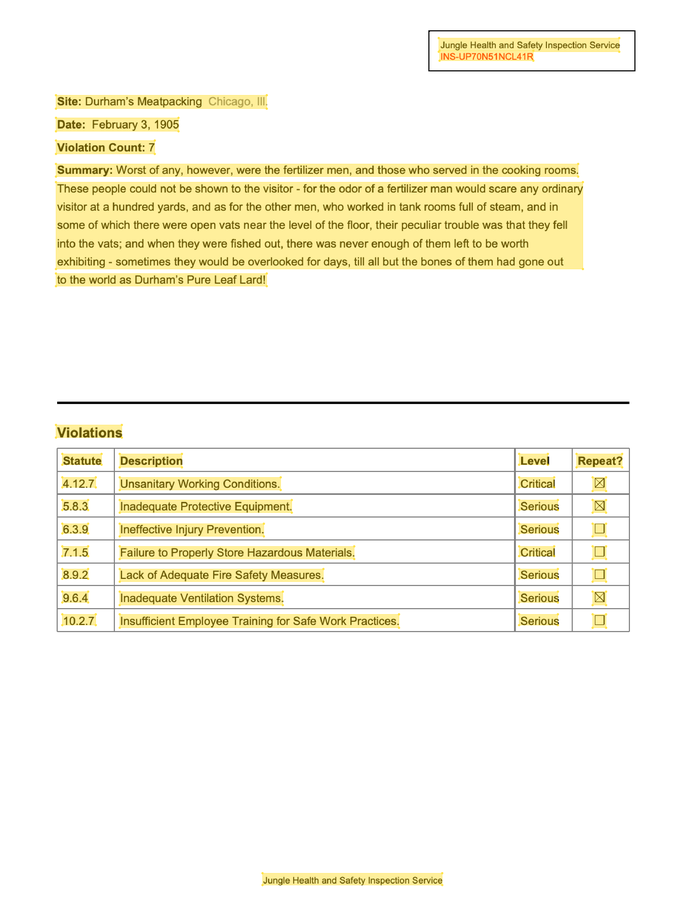

In [12]:
page.find_all('text').show(width=700)

## Advanced OCR with an LLM

Sometimes you need *exact* bounding boxes, or the LLM is being unpredictable, or you need to zoom in, or you need... all sorts of things. And alternative to throwing everything over the fence is a two-stop process:

1. Use an OCR tool with `detect_only=True` so it detects the text, but *doesn't try to read it*.
2. Then send each box to the LLM to get the text

I find this works better than sending the entire page because there is less likelihood for hallucination.

In [13]:
from natural_pdf import PDF
pdf = PDF("https://github.com/jsoma/natural-pdf/raw/refs/heads/main/pdfs/needs-ocr.pdf")
page = pdf.pages[0]

page.apply_ocr(detect_only=True)
page.extract_text()

''

''

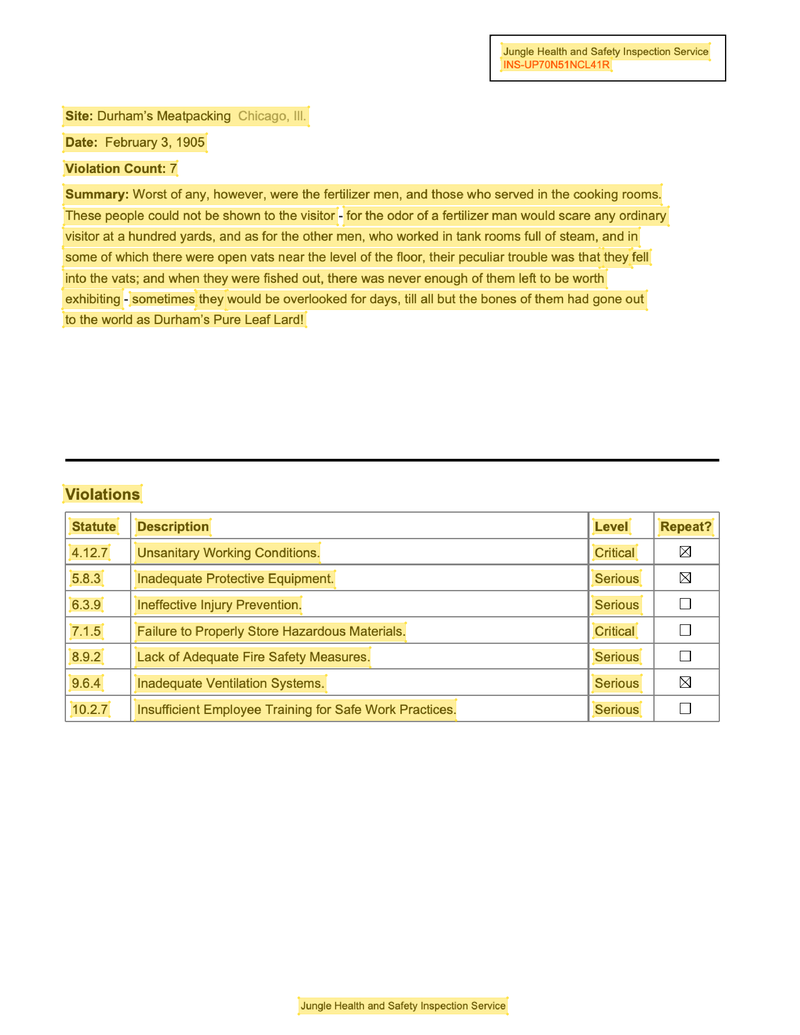

In [14]:
texts = page.find_all('text')
texts.show(width=800)

In [15]:
import os
from openai import OpenAI

instructions = """Return only the exact text content visible in the image. 
Preserve original spelling, capitalization, punctuation, and symbols.
Fix misspellings if they are the result of blurry or incorrect OCR.
Do not add any explanatory text, translations, comments, or quotation marks around the result.
If you cannot process the image or do not see any text, return an empty space.
The text is from an inspection report of a slaughterhouse."""
# Could use all other sorts of text, too
# The text is likely from a Greek document, potentially a spreadsheet, containing Modern Greek words or numbers

client = OpenAI(
    api_key=GOOGLE_API_KEY,
    # api_key="YOUR_API_KEY_HERE",
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
)

(
    page.find_all('text')
        .apply_ocr(
            engine="vlm",
            model="gemini-2.5-flash-lite",
            client=client,
            instructions=instructions
        )
)

Correcting OCR (ElementCollection(len=45)):   0%|          | 0/45 [00:00<?, ?element/s]

<ElementCollection[TextElement](count=45)>

What do we have now?

In [14]:
text = page.extract_text()
print(text)

Jungle Health and Safety Inspection Service
INS-UP70N51NCL41R
Site: Durham's Meatpacking Chicago, Ill.
Date: February 3, 1905
Violation Count: 7
Summary: Worst of any, however, were the fertilizer men, and those who served in the cooking rooms.
These people could not be shown to the visitor - for the odor of a fertilizer man would scare any ordinary
visitor at a hundred yards, and as for the other men, who worked in tank rooms full of steam, and in
some of which there were open vats near the level of the floor, their peculiar trouble was that they fell
into the vats; and when they were fished out, there was never enough of them left to be worth
exhibiting - sometimes they would be overlooked for days, till all but the bones of them had gone out
to the world as Durham's Pure Leaf Lard!
Violations
Statute Description Level Repeat?
4.12.7 Unsanitary Working Conditions. Critical X
5.8.3 Inadequate Protective Equipment. Serious X
6.3.9 Ineffective Injury Prevention. Serious
7.1.5 Failure to

## Finding tables on OCR documents

When we used `page.extract_table()` last time, it was easy because there were all of these `line` elements on the page that pdfplumber could detect and say "hey, it's a table!" For the same reason that there's no *real* text on the page, there's also no *real* lines on the page. Instead, we're going to do a fun secret trick where we look at what horizontal and vertical coordinates *seem* like they might be lines by setting a threshold.

/Users/soma/Development/natural-pdf/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


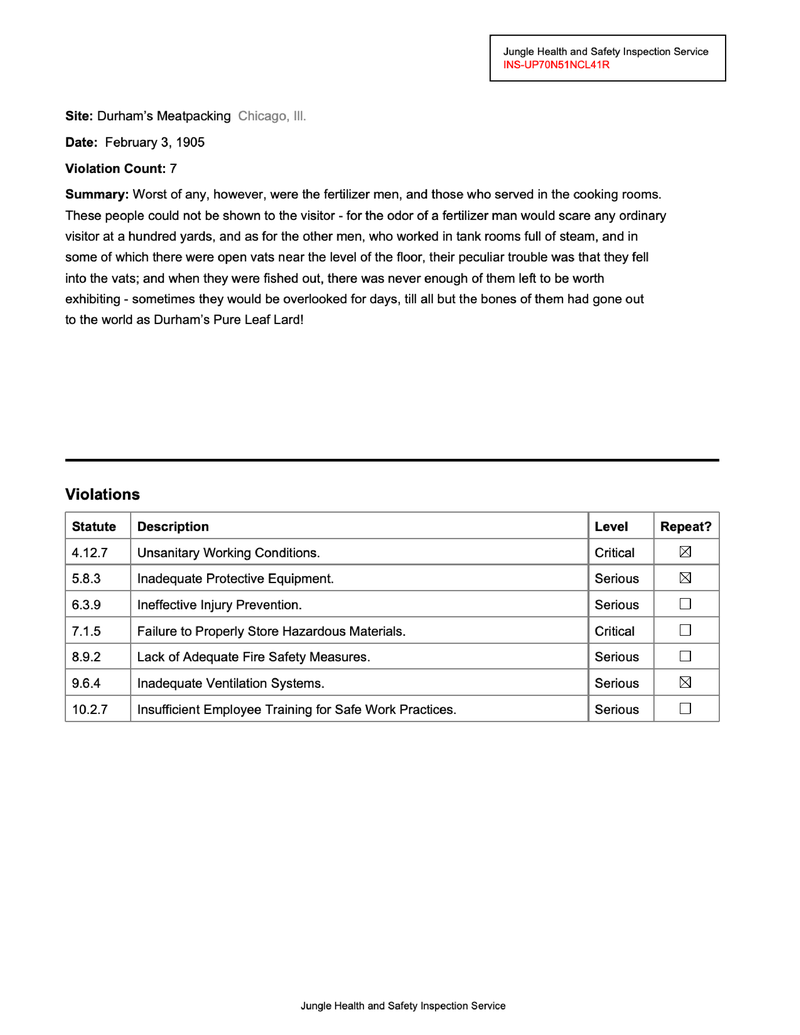

In [15]:
from natural_pdf import PDF

pdf = PDF("https://github.com/jsoma/natural-pdf/raw/refs/heads/main/pdfs/needs-ocr.pdf")
page = pdf.pages[0]

page.apply_ocr()
page.show(width=800)

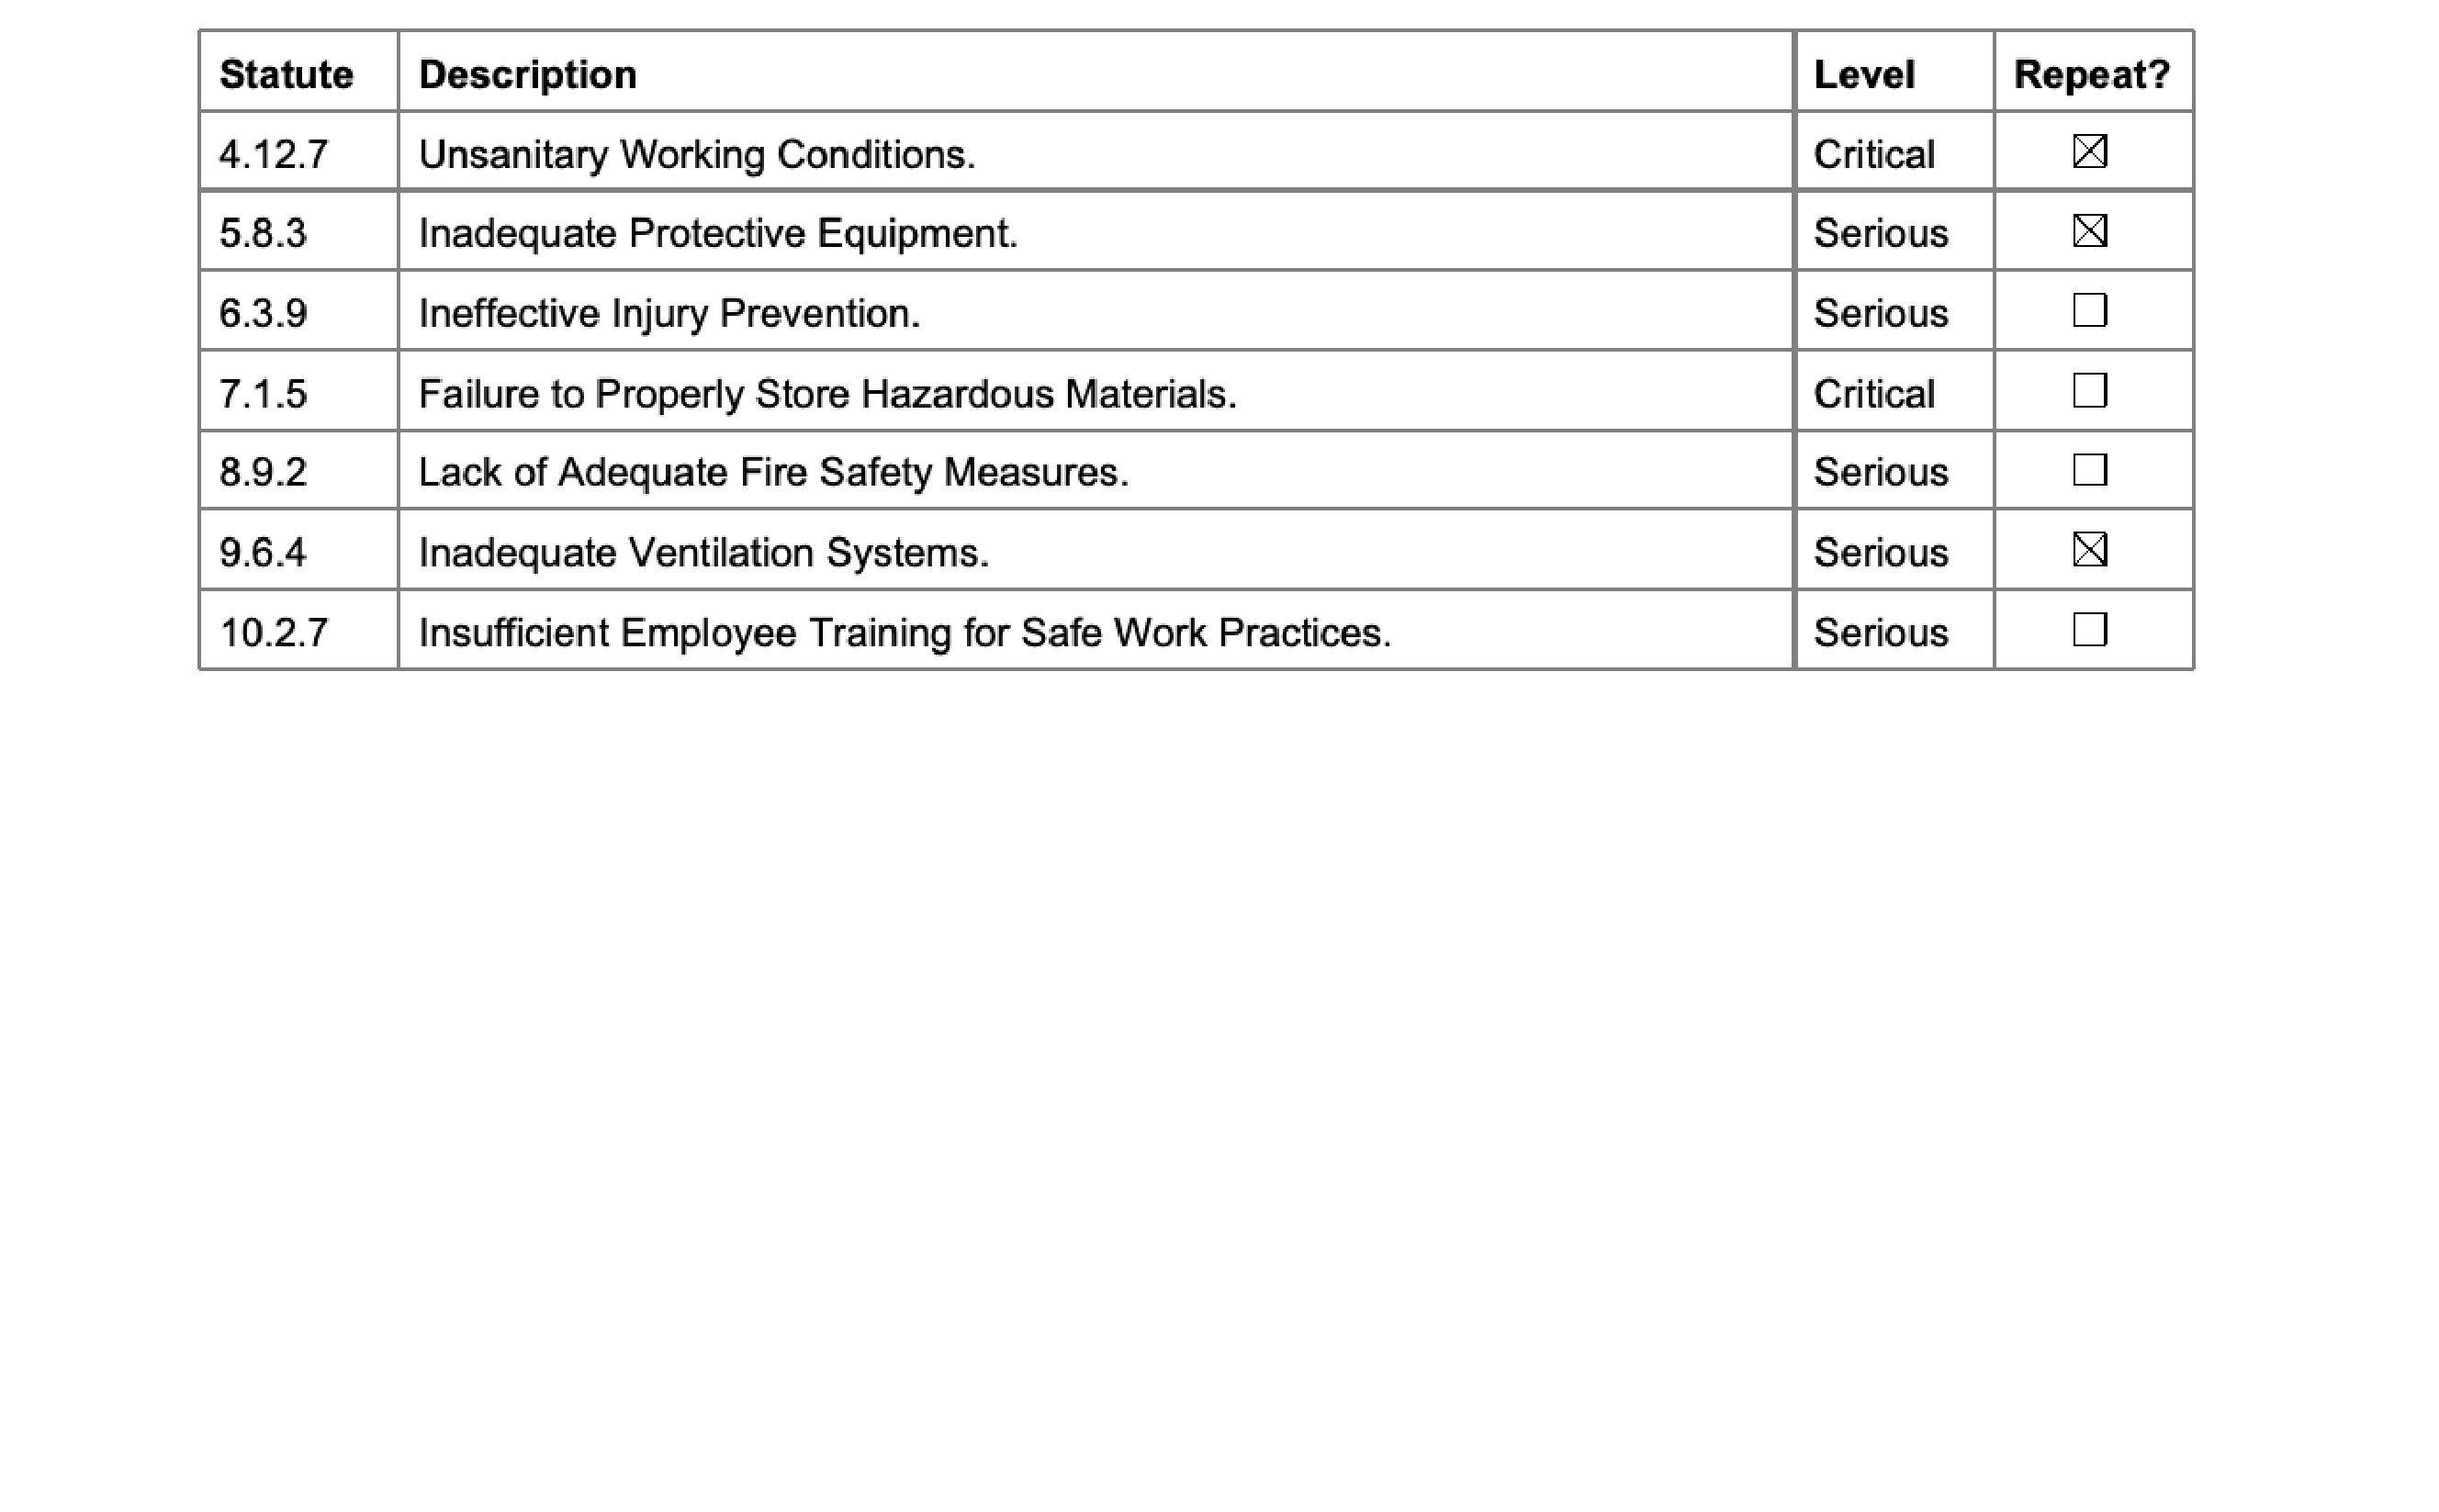

In [16]:
table_area = (
    page
    .find('text:contains(Violations)')
    .below(
        until='text:contains(Jungle)',
        include_endpoint=False
    )
)
table_area.show(crop=True)

Now we can add the lines and use them to detect the table.

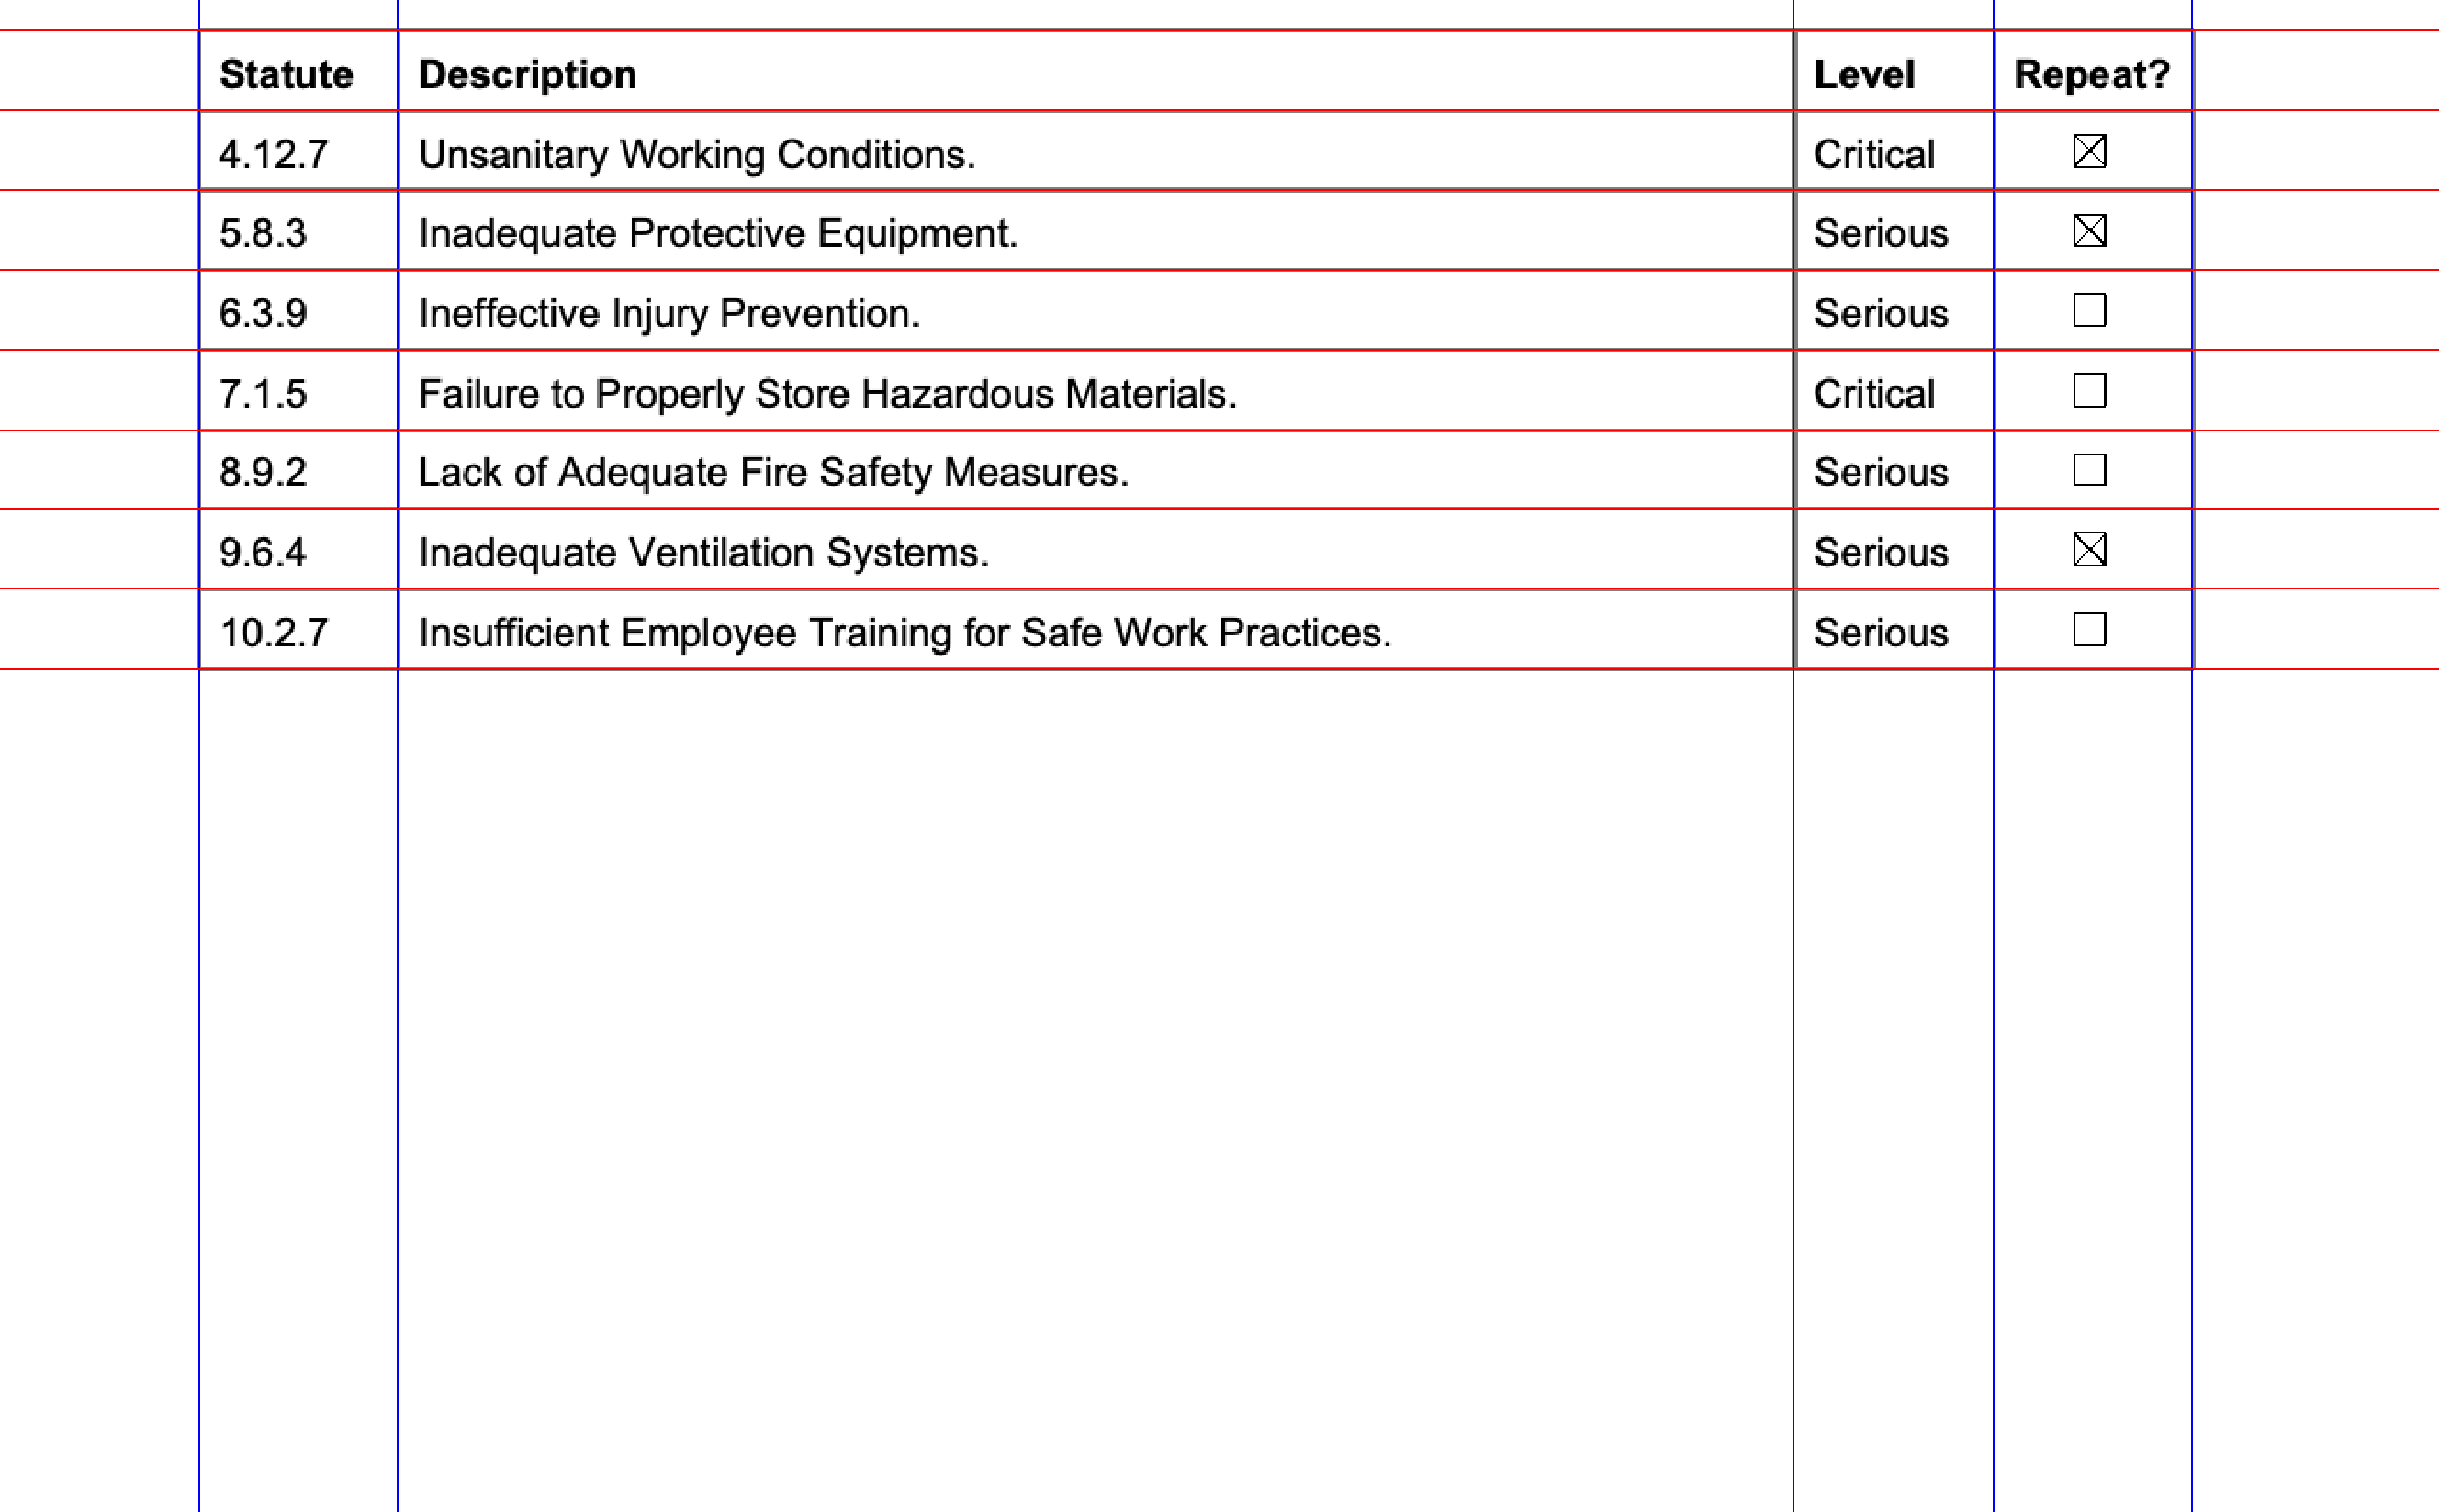

In [17]:
guides = table_area.guides()
guides.vertical.from_lines(threshold=0.4)
guides.horizontal.from_lines()
guides.show()

In [18]:
guides.extract_table().to_df()

,Statute,Description,Level,Repeat?
0,4.12.7,Unsanitary Working Conditions.,Critical,None
1,5.8.3,Inadequate Protective Equipment,Serious,None
2,6.3.9,Ineffective Injury Prevention_,Serious,None
3,7.1.5,Failure to Properly Store Hazardous Materials,Critical,None
4,8.9.2,Lack of Adequate Fire Safety Measures,Serious,None
5,9.6.4,Inadequate Ventilation Systems.,Serious,None
6,10.2.7,Insufficient Employee Training for Safe Work P...,Serious,None


### Figuring out information about things that are *not* text

In a tiny preview of the next notebook: **what about those checkboxes?** Turns out we can use **image classification AI** to do it for us in the next notebook!

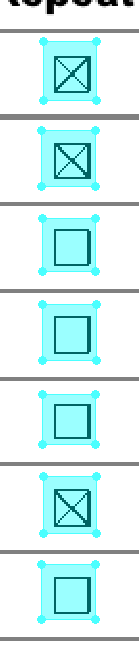

In [19]:
page.detect_checkboxes()
page.find_all('region').show(crop=20)

In [20]:
guides.extract_table().to_df()

,Statute,Description,Level,Repeat?
0,4.12.7,Unsanitary Working Conditions.,Critical,[CHECKED]
1,5.8.3,Inadequate Protective Equipment,Serious,[CHECKED]
2,6.3.9,Ineffective Injury Prevention_,Serious,[UNCHECKED]
3,7.1.5,Failure to Properly Store Hazardous Materials,Critical,[UNCHECKED]
4,8.9.2,Lack of Adequate Fire Safety Measures,Serious,[UNCHECKED]
5,9.6.4,Inadequate Ventilation Systems.,Serious,[CHECKED]
6,10.2.7,Insufficient Employee Training for Safe Work P...,Serious,[UNCHECKED]
